# 01 — Generative vs Discriminative Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Compare generative models (learn p(x, y) — can *create* data) and discriminative models (learn p(y|x) — can only *label* data)
- See both paradigms trained on the same dataset, side by side
- Preview a GAN — the modern deep generative model you will build in example 05

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 5, lesson 02, which carries the same title and drew the p(x,y) vs p(y|x) distinction; every classifier trained in Course 04 (AIAT 114) was on the discriminative side of it, and the GAN preview here uses the PyTorch training loop from Course 08 (AIAT 122) — Unit 1.

**Used later in:** Course 10 — Unit 1, lesson 05, which builds the GAN previewed at the end of this notebook.

---

## Introduction

A **discriminative** model learns the boundary between classes: it models p(y|x) and can answer "which class is this?" — nothing more.
A **generative** model learns what the data itself looks like: it models p(x|y) (or p(x)) and can therefore **sample brand-new data points**, as well as classify via Bayes' rule.

Below we train one of each on the same 2-D dataset and visualize exactly what each one learns.

---

## 🌍 Why this lesson exists — Bayesian spam filtering, 2002–2003

The first generative model most people relied on daily was a spam filter. In *Better Bayesian Filtering* (January 2003) Paul Graham reported that his naive-Bayes filter caught about **99.75%** of spam over a month, with **five false positives out of roughly 7,740 legitimate emails (0.06%)**. The mechanism is the one you are about to train below: model what spam text *looks like* and what normal mail *looks like* — p(words | class) per class — then classify with Bayes' rule. `GaussianNB` in Part 1 is the same idea with Gaussians instead of word counts.

**What goes wrong without this:** a purely discriminative filter learns only where today's boundary sits. It cannot answer "is this email unlike anything I have ever seen?", and it cannot produce examples of a class you are short of. When a new kind of spam arrives, a boundary model has no notion of what spam *is* — only of where the old line was drawn.

**The same reasoning appears in:** transaction fraud scoring (model normal spending, flag the improbable), network intrusion baselining, and equipment monitoring where the failures you must catch have never occurred yet.


## Part 1 — The Two Paradigms on the Same Dataset

We use a simple 2-class, 2-D dataset so everything is visible:

- **Generative model**: Gaussian Naive Bayes — fits a Gaussian distribution *per class* (this IS a model of p(x|y)), classifies with Bayes' rule, and can **sample new points** from the fitted Gaussians.
- **Discriminative model**: Logistic Regression — fits only the decision boundary p(y|x); it has no idea what the data looks like away from the boundary and **cannot generate anything**.


Test accuracy — generative (GaussianNB):        97.2%
Test accuracy — discriminative (LogisticReg.):  96.1%


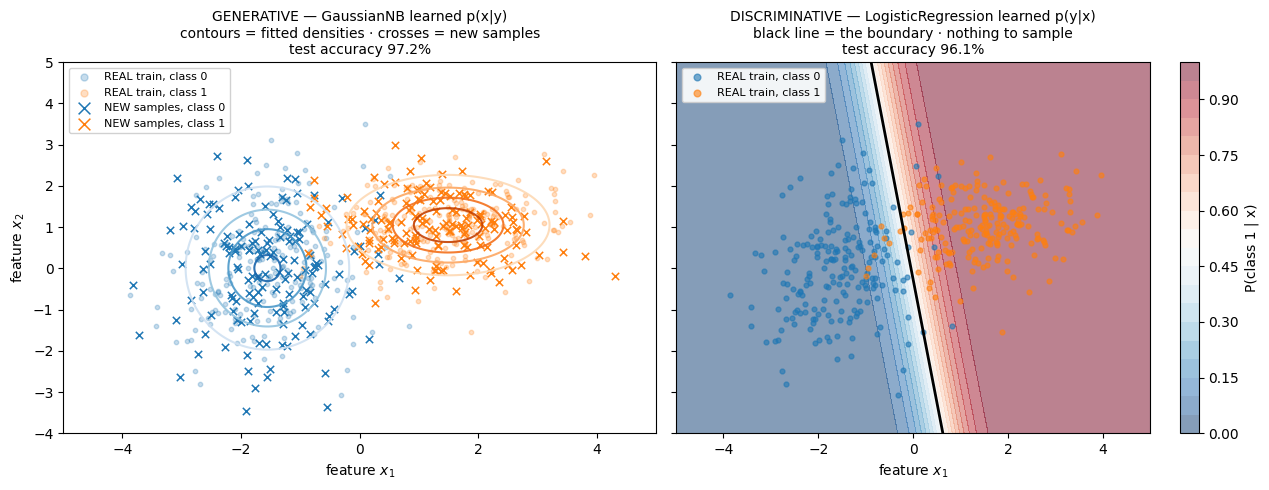


Key point: both models classify well, but only the generative model
also learned the data distribution — so only it can generate new points.


In [1]:
# WHAT/WHY: train a generative model (Gaussian Naive Bayes) and a discriminative
# model (Logistic Regression) on the SAME 2-D dataset, then visualize what each
# one learned — the generative model can sample new data; the discriminative
# model only draws a boundary. This is the core comparison of this lesson.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)

# ── Build a 2-class, 2-D dataset (two Gaussian blobs) ─────────────────────
n_per_class = 300
X0 = rng.normal(loc=[-1.5, 0.0], scale=[0.8, 1.2], size=(n_per_class, 2))  # class 0
X1 = rng.normal(loc=[+1.5, 1.0], scale=[1.0, 0.7], size=(n_per_class, 2))  # class 1
X = np.vstack([X0, X1])
y = np.array([0] * n_per_class + [1] * n_per_class)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

# ── Fit both models on the same training split ────────────────────────────
gen_model  = GaussianNB().fit(X_tr, y_tr)           # generative: one Gaussian per class
disc_model = LogisticRegression().fit(X_tr, y_tr)   # discriminative: boundary only

# ── Both can classify — print held-out accuracy for each ──────────────────
acc_gen  = gen_model.score(X_te, y_te)
acc_disc = disc_model.score(X_te, y_te)
print(f"Test accuracy — generative (GaussianNB):        {acc_gen*100:.1f}%")
print(f"Test accuracy — discriminative (LogisticReg.):  {acc_disc*100:.1f}%")

# ── Only the GENERATIVE model can create new data ─────────────────────────
# Sample from the per-class Gaussians the model fitted (mean theta_, var var_).
def sample_from_gnb(model, cls, n):
    mean = model.theta_[cls]          # fitted class mean
    std  = np.sqrt(model.var_[cls])   # fitted class std (diagonal covariance)
    return rng.normal(mean, std, size=(n, 2))

new0 = sample_from_gnb(gen_model, 0, 150)  # brand-new synthetic class-0 points
new1 = sample_from_gnb(gen_model, 1, 150)  # brand-new synthetic class-1 points

# ── Visualization: generative view (left) vs discriminative view (right) ──
# Both panels share one x/y range so the two views are directly comparable.
xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-4, 5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

# Left: what the generative model learned — class densities, the REAL training
# points (faint dots) and the model's NEW samples (crosses) on the same axes, so
# you can check that the invented points land where the real data actually lives.
for cls, cmap_name, color in [(0, "Blues", "tab:blue"), (1, "Oranges", "tab:orange")]:
    dens = multivariate_normal(gen_model.theta_[cls], np.diag(gen_model.var_[cls])).pdf(grid)
    axes[0].contour(xx, yy, dens.reshape(xx.shape), levels=4, cmap=cmap_name, alpha=0.9)
axes[0].scatter(X_tr[y_tr == 0, 0], X_tr[y_tr == 0, 1], c="tab:blue",   s=10, alpha=0.25, label="REAL train, class 0")
axes[0].scatter(X_tr[y_tr == 1, 0], X_tr[y_tr == 1, 1], c="tab:orange", s=10, alpha=0.25, label="REAL train, class 1")
axes[0].scatter(new0[:, 0], new0[:, 1], c="tab:blue",   marker="x", s=28, linewidths=1.1, label="NEW samples, class 0")
axes[0].scatter(new1[:, 0], new1[:, 1], c="tab:orange", marker="x", s=28, linewidths=1.1, label="NEW samples, class 1")
axes[0].set_title("GENERATIVE — GaussianNB learned p(x|y)\n"
                  "contours = fitted densities · crosses = new samples\n"
                  f"test accuracy {acc_gen*100:.1f}%", fontsize=10)
axes[0].set_xlabel("feature $x_1$"); axes[0].set_ylabel("feature $x_2$")
axes[0].legend(loc="upper left", fontsize=8, framealpha=0.9, markerscale=1.6)

# Right: what the discriminative model learned — only a decision boundary
proba = disc_model.predict_proba(grid)[:, 1].reshape(xx.shape)
cf = axes[1].contourf(xx, yy, proba, levels=20, cmap="RdBu_r", alpha=0.5)
axes[1].contour(xx, yy, proba, levels=[0.5], colors="black", linewidths=2)
axes[1].scatter(X_tr[y_tr == 0, 0], X_tr[y_tr == 0, 1], c="tab:blue",   s=12, alpha=0.6, label="REAL train, class 0")
axes[1].scatter(X_tr[y_tr == 1, 0], X_tr[y_tr == 1, 1], c="tab:orange", s=12, alpha=0.6, label="REAL train, class 1")
axes[1].set_title("DISCRIMINATIVE — LogisticRegression learned p(y|x)\n"
                  "black line = the boundary · nothing to sample\n"
                  f"test accuracy {acc_disc*100:.1f}%", fontsize=10)
axes[1].set_xlabel("feature $x_1$")
axes[1].legend(loc="upper left", fontsize=8, framealpha=0.9, markerscale=1.4)
fig.colorbar(cf, ax=axes[1], label="P(class 1 | x)")
plt.tight_layout(); plt.show()

print("\nKey point: both models classify well, but only the generative model")
print("also learned the data distribution — so only it can generate new points.")


**Read the figure.** Both panels plot the same two features on the same axes.

*Left (generative).* The faint dots are the real training points; the crosses are 300 points the fitted model **invented**, and the contour rings are the two Gaussians it fitted — one per class. The crosses sit on top of the real dots and spread the same way, which is the whole claim: this model learned *what the data looks like*, so it can produce more of it. Nothing on this panel required a boundary.

*Right (discriminative).* Same data, but all the model stored is the red/blue probability field and the black 0.5 line. Move away from that line in any direction and the model still answers confidently — it has no notion of where data actually lives, and there is nothing here to draw a new point from.

Both reach almost the same test accuracy (printed above the panels). Accuracy is not what separates them; **the ability to sample is.**

## Part 2 — Preview: a GAN, the Modern Deep Generative Model

The Gaussian model above works because our toy data really is Gaussian. Real data (images, audio, text) is far too complex for a hand-picked distribution — so modern generative models **learn** the distribution with neural networks. The most famous example is the **GAN (Generative Adversarial Network)**.

**How the training below works** (you will build this yourself, step by step, in example 05 — here it is a preview):

- The **Generator (G)** is a neural network that maps random noise `z` → a 28×28 image. It plays the *generative* role.
- The **Discriminator (D)** is a neural network that maps an image → "probability it is real". It is literally a *discriminative* classifier — this lesson's two paradigms working together!
- Training alternates every batch:
  1. **D step**: show D real images labeled 1 and G's fakes labeled 0; update D to tell them apart. (`G(z).detach()` stops this step from also updating G.)
  2. **G step**: update G so that D scores its fakes as 1 — i.e., G improves by learning to *fool* D.
- As D gets stricter, G gets better — until G's samples start to look like real digits.

**Industry context:** GANs are used to generate synthetic training data (e.g., for autonomous-driving datasets), candidate molecular structures in drug discovery, and design mockups in fashion.

The network below is a small **fully-connected GAN** (a real DCGAN uses convolutional layers — see the references). Fourteen quick epochs on a 12,800-image MNIST subset — about ten seconds on a laptop CPU — are enough to watch digit-like shapes emerge from noise.


Epoch  1/14 — D loss: 1.093  G loss: 1.010


Epoch  2/14 — D loss: 0.822  G loss: 1.025


Epoch  4/14 — D loss: 0.489  G loss: 2.176


Epoch  8/14 — D loss: 0.926  G loss: 1.030


Epoch 14/14 — D loss: 0.861  G loss: 1.535


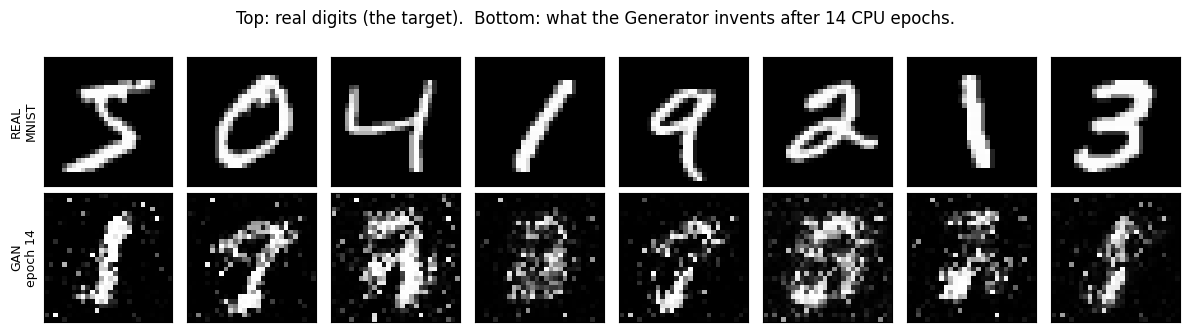

In [2]:
# WHAT/WHY: preview of GAN training — a Generator learns to turn random noise
# into digit images by trying to fool a Discriminator. Full walkthrough in
# example 05; here, watch the adversarial loop run and look at the samples.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

# ── Data: MNIST scaled to [-1, 1] to match the Generator's Tanh output ────
transform = T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])])
dataset   = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=transform)
# Classroom-sized subset: 12,800 images keep this preview fast on CPU
subset    = torch.utils.data.Subset(dataset, range(12_800))
loader    = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

# ── Generator: noise vector (64) → flattened 28×28 image ──────────────────
G = nn.Sequential(
    nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512),        nn.LeakyReLU(0.2),
    nn.Linear(512, 28*28),      nn.Tanh()
)
# ── Discriminator: flattened image → probability it is real ───────────────
D = nn.Sequential(
    nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(512, 256),   nn.LeakyReLU(0.2), nn.Dropout(0.3),
    nn.Linear(256, 1),     nn.Sigmoid()
)
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce   = nn.BCELoss()

d_losses, g_losses = [], []
EPOCHS = 14        # ~10 s on CPU — long enough for digit-like strokes to appear
SNAP_AT = [1, 2, 4, 8, 14]   # epochs to photograph for the storyboard below

# ── Storyboard capture: ONE fixed batch of latent vectors, decoded after every
# epoch. Because z never changes, the grid below shows the SAME eight images
# improving — not eight new lucky draws each time.
# Drawn from its OWN generator so the storyboard does not disturb the random
# stream the training loop uses — the numbers below stay reproducible.
snap_rng = torch.Generator().manual_seed(7)
fixed_z  = torch.randn(8, LATENT_DIM, generator=snap_rng)
snap_labels = ["untrained"]
with torch.no_grad():
    snapshots = [G(fixed_z).view(8, 28, 28).numpy()]   # epoch 0: G is untrained noise

for epoch in range(1, EPOCHS + 1):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0)
        real_flat = real_imgs.view(bs, -1)
        # ── D step: real images → label 1, G's fakes → label 0 ────────────
        z    = torch.randn(bs, LATENT_DIM)
        fake = G(z).detach()  # detach: this step must not update G
        loss_D = bce(D(real_flat), torch.ones(bs, 1)) + bce(D(fake), torch.zeros(bs, 1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # ── G step: update G so D scores its fakes as "real" (label 1) ────
        z      = torch.randn(bs, LATENT_DIM)
        fake   = G(z)
        loss_G = bce(D(fake), torch.ones(bs, 1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    if epoch in SNAP_AT:   # photograph only a few epochs — a readable storyboard
        d_losses.append(loss_D.item()); g_losses.append(loss_G.item())
        with torch.no_grad():
            snapshots.append(G(fixed_z).view(8, 28, 28).numpy())  # same z, later in training
        snap_labels.append(f"epoch {epoch}")
        print(f"Epoch {epoch:>2}/{EPOCHS} — D loss: {d_losses[-1]:.3f}  G loss: {g_losses[-1]:.3f}")

# ── The honest test: put the GAN's output NEXT TO the real thing ──────────
# Top row = the first 8 real MNIST images the Discriminator was trained on.
# Bottom row = 8 fresh samples from the trained Generator, same grey scale.
# Side by side you can judge for yourself how far 14 CPU epochs actually gets.
G.eval()
with torch.no_grad():
    samples = G(torch.randn(8, LATENT_DIM)).view(8, 28, 28).numpy()
reals = np.stack([subset[i][0].view(28, 28).numpy() for i in range(8)])

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for c in range(8):
    axes[0, c].imshow(reals[c],   cmap='gray', vmin=-1, vmax=1)
    axes[1, c].imshow(samples[c], cmap='gray', vmin=-1, vmax=1)
    for r in range(2):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
axes[0, 0].set_ylabel("REAL\nMNIST", fontsize=9)
axes[1, 0].set_ylabel(f"GAN\nepoch {EPOCHS}", fontsize=9)
plt.suptitle("Top: real digits (the target).  Bottom: what the Generator invents after 14 CPU epochs.")
plt.tight_layout(); plt.show()


**Read the figure.** The top row is the target the Generator is chasing: eight real MNIST digits — clean single strokes, smooth edges, black background.

The bottom row is what the Generator produces from pure noise after 14 CPU epochs. Compare them honestly: the GAN has clearly learned the *global grammar* of MNIST — white ink on a black field, one connected blob of stroke in the middle of the frame, roughly digit-sized. It has **not** learned clean digits. The strokes are ragged and speckled, and several samples are shapes that no one would write down as a number.

That gap is the point. Nobody wrote a rule saying "white strokes on black" — the Generator inferred it purely from the Discriminator's push-back. And the gap that remains is a budget gap, not a conceptual one: example 05 trains this architecture properly, and Unit 3 replaces it with convolutional and diffusion models that close it.

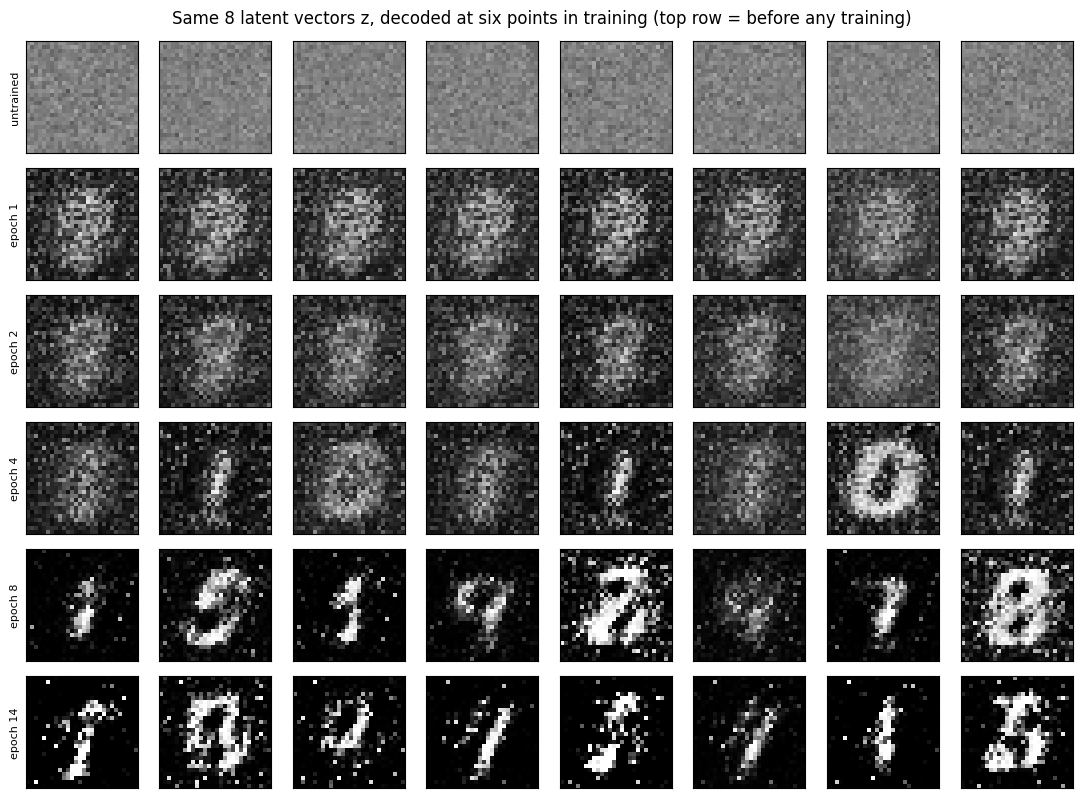

row  state           ink   z-spread   D loss   G loss
0    untrained     0.085      0.073      —        —  
1    epoch 1       0.488      0.084    1.093    1.010
2    epoch 2       0.502      0.101    0.822    1.025
3    epoch 4       0.614      0.196    0.489    2.176
4    epoch 8       0.830      0.300    0.926    1.030
5    epoch 14      0.913      0.273    0.861    1.535


In [3]:
# WHAT/WHY: a frame-by-frame storyboard of the generator learning. Each ROW is
# one photographed epoch; each COLUMN is one of the eight FIXED latent vectors
# captured during training above. Reading DOWN a column shows what that single z
# decoded to as training progressed — the "digits emerge from noise" claim, made
# visible. z never changes between rows, so every difference is G's weights.
fig, axes = plt.subplots(len(snapshots), 8, figsize=(11, 1.35 * len(snapshots)))
for r, frame in enumerate(snapshots):
    for c in range(8):
        axes[r, c].imshow(frame[c], cmap='gray', vmin=-1, vmax=1)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
    axes[r, 0].set_ylabel(snap_labels[r], fontsize=8)
plt.suptitle("Same 8 latent vectors z, decoded at six points in training (top row = before any training)")
plt.tight_layout(); plt.show()

# Printed step table so the storyboard has numbers beside it.
# ink      = mean |pixel|; near 0 means everything is flat mid-grey.
# z-spread = mean pixel std ACROSS the 8 panels of a row; near 0 means G is
#            producing the same picture whatever z it is given (ignoring z).
print(f"{'row':<5}{'state':<12}{'ink':>7}{'z-spread':>11}{'D loss':>9}{'G loss':>9}")
for r, frame in enumerate(snapshots):
    dl = "   —  " if r == 0 else f"{d_losses[r-1]:.3f}"
    gl = "   —  " if r == 0 else f"{g_losses[r-1]:.3f}"
    print(f"{r:<5}{snap_labels[r]:<12}{abs(frame).mean():>7.3f}{frame.std(axis=0).mean():>11.3f}{dl:>9}{gl:>9}")


**Read the storyboard.** Every column is one fixed latent vector `z`; every row is one photographed epoch. Read down a column and you are watching a single `z` become a picture.

**Row 1 — untrained.** All eight panels are flat grey static, and the table says why: `ink` (mean |pixel|) is about 0.09, i.e. everything sits near mid-grey. An untrained decoder carries no information about digits at all.

**Rows 2–3 — epochs 1 and 2.** The whole row changes character: black borders, a bright smear of "ink" in the middle, and `ink` jumps roughly five-fold as G starts using the full black-to-white range. This is G learning the *global* statistics of MNIST — white strokes on a black field — before it learns any particular digit. Note that the eight panels still look almost the same as each other, and `z-spread` is still only ~0.08–0.10: G is producing one average-ish output regardless of which `z` it is handed.

**Row 4 — epoch 4.** The smear resolves into strokes. Panels start to differ from one another, and `z-spread` roughly doubles — that is G beginning to *use* `z` instead of ignoring it.

**Rows 5–6 — epochs 8 and 14.** The background goes properly black, single connected strokes appear, and several panels are now shapes you would read as digits at a glance. `z-spread` is around 0.3 — roughly four times the untrained value — so the eight columns have become eight *different* outputs. They are still ragged and speckled: 14 epochs of a small fully-connected GAN buys digit-*like* shapes, which is exactly the limit the real-vs-generated figure above shows.

Nothing about `z` changed between rows, so **every bit of this improvement is in G's weights** — which is precisely what the adversarial loop updates. The discriminative model in the first figure has no equivalent storyboard to show: there is nothing to decode, because it never learned what the data looks like.

## 💬 Discuss

Argue these out — the printed numbers above support more than one defensible answer.

1. Our generative model scored **97.2%** and the discriminative one **96.1%**. Suppose those two numbers had come out the other way round. Would that change your recommendation for a spam filter that must *also* flag mail unlike anything it has seen? Say what the accuracy number does and does not settle.
2. Graham's filter was judged mainly on false positives — one deleted legitimate email is worse than ten spams in the inbox. Now look at the GAN preview: what is the equivalent "worse error" for a generator, and who pays for it? Pick a threshold policy for each and defend it.
3. Ng & Jordan (2001) argued generative classifiers win with little data and lose with a lot. Our gap is 1.1 points, measured on a held-out split of 180 points out of 600. Design the experiment that would tell you whether that gap is real or noise — what would you vary, and what would convince you?


## ⚠️ Where this breaks

**The assumption that must hold:** the generative model assumes a *shape* for p(x|y). `GaussianNB` won here because our two blobs really are Gaussian with roughly diagonal covariance — we built them that way. Feed it a crescent-shaped or multi-modal class and its boundary becomes worse than logistic regression's, which assumes nothing about class shapes at all.

**When to use the discriminative model instead:** Ng & Jordan (2001) showed generative classifiers reach their asymptotic error faster but that error is higher. With plenty of labels and only a labelling job to do, the discriminative model is cheaper to train, cheaper to serve, and more accurate. Modelling p(x) is work you should do only when you need what p(x) buys: sampling, anomaly scoring, or missing-value handling.

**Do not read "generative" as "better".** The GAN preview trained two networks for fourteen epochs and produced digit-*like* strokes, not clean digits — the side-by-side with real MNIST above shows exactly how large the remaining gap is. It answers a different question at a much higher training cost, and it gives you no likelihood at all — you cannot ask it "how probable is this image?", which is exactly what the little Gaussian model above could answer for free.


---

## ✅ Summary

**What you learned:**
- **Discriminative models** learn p(y|x): great at labeling, unable to create. Our logistic regression classified the toy data well but has nothing to sample from.
- **Generative models** learn the data distribution: our Gaussian model classified *and* produced brand-new points that landed on top of the real data.
- **GAN preview**: modern generative models learn complex distributions with neural networks — a Generator (generative role) trained adversarially against a Discriminator (discriminative role). Example 05 builds this in full detail.

**Next steps:**
- Example 02 compares the main deep generative *families* (GANs, VAEs, flows)
- Example 03 goes deeper into probabilistic generative models and log-likelihood


## 📚 References & Further Reading

**Foundational Papers:**
- Ng & Jordan (2001) — [On Discriminative vs. Generative Classifiers](https://papers.nips.cc/paper/2020-on-discriminative-vs-generative-classifiers) *(the classic comparison)*
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(invented GANs)*
- Radford et al. (2015) — [DCGAN](https://arxiv.org/abs/1511.06434) *(the convolutional GAN our preview simplifies)*

**Survey:**
- Bond-Taylor et al. (2021) — [Deep Generative Modelling: A Comparative Review](https://arxiv.org/abs/2103.04922) *(VAEs, GANs, flows, autoregressive and energy-based models in one map)*

**State-of-the-Art:**
- Modern image generators (DALL-E, Midjourney, Stable Diffusion) combine these generative ideas with diffusion — taught in Unit 3

**Recent (2024–2026):**
- Lipman et al. (2024) — [Flow Matching Guide and Code](https://arxiv.org/abs/2412.06264) *(how p(x) is learned in 2026: regress a velocity field that carries noise to data, instead of playing an adversarial game — a self-contained review with code)*
- Zhao et al. (2025) — [Unified Multimodal Understanding and Generation Models: Advances, Challenges, and Opportunities](https://arxiv.org/abs/2505.02567) *(the survey of models that both *interpret* and *produce* images — the two roles this notebook contrasts, merged into one network)*
